# Iteration 8: RQ3 - Hazard Type Classification using Process Safety Trained LLM

## Objective
This iteration addresses Research Question 3 (RQ3) by:
1. Extracting and analyzing the HAZARD column from all datasets
2. Identifying fixed hazard types across all countries
3. Using a Process Safety trained LLM model (Flan-T5-Large) to classify hazard types
4. Building comprehensive hazard type taxonomy
5. Correlating hazard types with process safety incidents

## Data Source
- 4 JSON files from By_Country folder: German, Swedish, English, and UK
- HAZARD column contains raw hazard descriptions

## Methodology
- Process Safety trained Flan-T5-Large model for zero-shot and few-shot classification
- Hazard type taxonomy development
- Cross-language hazard type analysis (German, Swedish, English)


In [ ]:
# =============================================================================
# IMPORTS AND CONFIGURATION — ITERATION 9
# =============================================================================
# Cross-platform path resolution (consistent with Iteration 0).
# Loads master_df.json produced by Iteration 0.

import os
import json
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import warnings
from collections import Counter, defaultdict
import pickle
import time
from pathlib import Path

warnings.filterwarnings('ignore')

def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError("Could not find project root with 'Datasets' folder.")

env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
    print(f"Using THESIS_BASE_DIR from environment: {BASE_DIR}")
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())
    print(f"Found project root: {BASE_DIR}")

PATHS = {
    'master_dataset': BASE_DIR / "Master Dataset 34k",
    'embeddings':     BASE_DIR / "Embeddings" / "_iteration_8",
    'results':        BASE_DIR / "Results" / "_iteration_8"
}

for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()
    PATHS[k].mkdir(parents=True, exist_ok=True)

DATA_DIR          = str(PATHS['master_dataset'])
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR       = str(PATHS['results'])
CHECKPOINT_FILE   = str(PATHS['results'] / "checkpoint_iteration_8.json")

# Language code mapping
LANGUAGE_CODE_MAP = {
    'English': 'EN', 'German': 'DE', 'Swedish': 'SV',
    'Dutch':   'NL', 'Hungarian': 'HU', 'Unknown': 'UN',
}

# Single source file: master_df.json from Iteration 0
MASTER_DF_FILE = str(PATHS['master_dataset'] / 'master_df.json')
print(f"[INFO] Master dataset file: {MASTER_DF_FILE}")
print(f"[INFO] File exists: {os.path.exists(MASTER_DF_FILE)}")

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"[INFO] Base directory:    {BASE_DIR}")
print(f"[INFO] Data directory:    {DATA_DIR}")
print(f"[INFO] Results directory: {RESULTS_DIR}")
print(f"[INFO] Device:            {device}")

# Load master_df.json
print("\n[INFO] Loading master_df.json...")
master_df = pd.read_json(MASTER_DF_FILE)
print(f"[OK] Loaded {len(master_df):,} records, {master_df['HAZARD'].nunique()} unique hazard values")
print(f"[INFO] Columns: {list(master_df.columns)}")
print(f"\n[INFO] Records by SL_COUNTRY:")
print(master_df['SL_COUNTRY'].value_counts().to_string())
print(f"\n[INFO] Process Safety records: {(master_df['CASE_TYPE']=='Process Safety').sum():,}")

# Build all_data dict grouped by SL_COUNTRY (preserves downstream cell structure)
all_data = {country: group.reset_index(drop=True)
            for country, group in master_df.groupby('SL_COUNTRY')}
print(f"\n[INFO] Grouped into {len(all_data)} country datasets")


Found project root: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
[INFO] Master dataset file: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k/master_df.json
[INFO] File exists: True
[INFO] Base directory:    /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
[INFO] Data directory:    /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k
[INFO] Results directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8
[INFO] Device:            mps

[INFO] Loading master_df.json...
[OK] Loaded 34,576 records, 261 unique hazard values
[INFO] Columns: ['CASENO', 'COMPANY', 'FUNCTIONAL_GROUP', 'FUNCTION', 'FUNCTIONAL_AREA', 'FUNCTIONAL_LOCATION', 'FUNCTIONAL_SUB_LOCATION', 'LOCATION_SID', 'LOCATION_SHORT', 'COUNTRY_SHORT', 'SL_COUNTRY', 'SL_LOCATION_LVL_1', 'SL_LOCATION_LVL_2', 'SL_LOCATION_LVL_3', 'SL_LOCATION_LVL_4', 'CASE_OCCURENCE_DATE', 'TITLE', 'COMPANY_INVOLVED_TYPE', 'CASE_TYPE', 'CASE

In [22]:
# ============================================================
# EXTRACT AND ANALYZE HAZARD COLUMN
# ============================================================
print("[INFO] Extracting hazard information from all datasets...\n")

all_hazards = []
hazard_by_country = {}
hazard_by_case_type = defaultdict(list)

for country, df in all_data.items():
    if 'HAZARD' in df.columns:
        # Extract non-null hazards
        hazards = df[df['HAZARD'].notna()]['HAZARD'].unique().tolist()
        hazard_by_country[country] = hazards
        all_hazards.extend(hazards)
        
        # Correlate with CASE_TYPE if available
        if 'CASE_TYPE' in df.columns:
            for idx, row in df[df['HAZARD'].notna()].iterrows():
                hazard_by_case_type[row['CASE_TYPE']].append(row['HAZARD'])

# Remove duplicates and get statistics
unique_hazards = list(set(all_hazards))
print(f"[OK] Total hazard records: {len(all_hazards)}")
print(f"[OK] Unique hazard types: {len(unique_hazards)}")
print(f"[OK] Countries with HAZARD data: {len(hazard_by_country)}")

# Show distribution by country
print(f"\n[INFO] Hazard distribution by country:")
for country in sorted(hazard_by_country.keys()):
    print(f"   {country:20s}: {len(hazard_by_country[country]):6d} unique hazards")

# Show distribution by case type
if hazard_by_case_type:
    print(f"\n[INFO] Hazard records by case type:")
    for case_type in sorted(hazard_by_case_type.keys(), key=str):
        print(f"   {str(case_type):30s}: {len(hazard_by_case_type[case_type]):6d} records")

[INFO] Extracting hazard information from all datasets...

[OK] Total hazard records: 762
[OK] Unique hazard types: 261
[OK] Countries with HAZARD data: 9

[INFO] Hazard distribution by country:
   Germany             :    222 unique hazards
   Hungary             :     68 unique hazards
   International       :     19 unique hazards
   Netherlands         :    162 unique hazards
   Poland              :      1 unique hazards
   Russia              :      8 unique hazards
   Sweden              :     54 unique hazards
   UAE                 :     18 unique hazards
   UK                  :    210 unique hazards

[INFO] Hazard records by case type:
   Asset and Reputation damage/loss:   1331 records
   Environment                   :   2735 records
   Information Security          :    185 records
   Not classified                :      8 records
   Operational loss              :    454 records
   Physical Security             :    100 records
   Process Safety                :   4504 r

[INFO] Filtered to Process Safety records: 4561
[INFO] After dropping missing HAZARD: 4561


Classifying hazards: 100%|██████████| 4561/4561 [16:06<00:00,  4.72it/s]



[INFO] Classification Report (macro-F1 shown below):
                                                                                                                      precision    recall  f1-score   support

                                                                                                  -- Not selected --       0.00      0.00      0.00       100
                                                                                                    Actuator failure       0.00      0.00      0.00        15
                                                                                                  Arcing / Flashover       0.00      0.00      0.00        10
                                                                                 Build up of an explosive atmosphere       0.00      0.00      0.00        24
                                                                                                            Chemical       0.00      0.00      0.00        

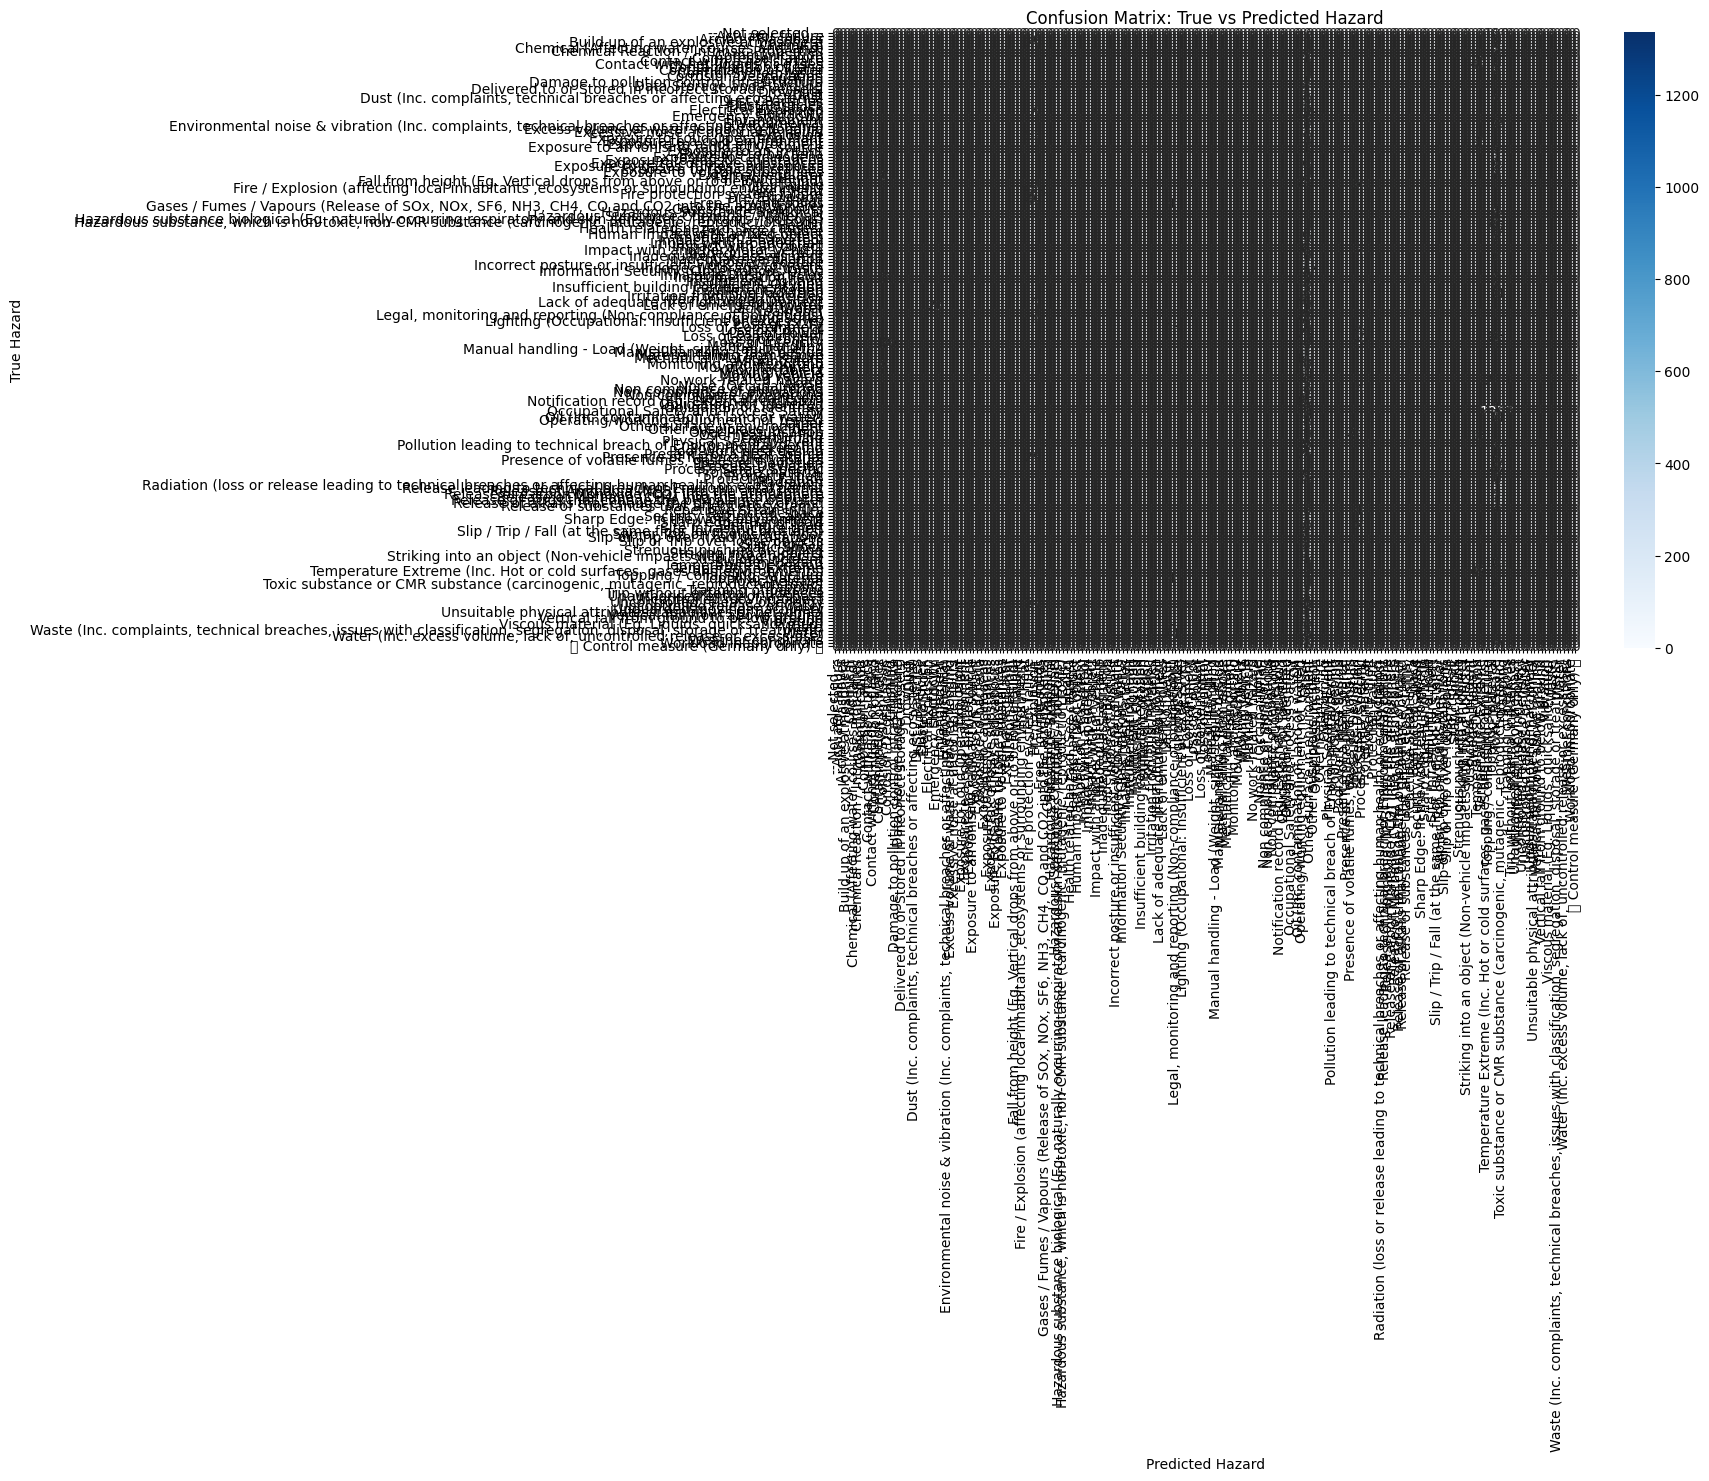

In [23]:
# ============================================================
# FILTER TO PROCESS SAFETY DATA ONLY (4561 records)
# ============================================================
process_safety_df = master_df[master_df['CASE_TYPE'] == 'Process Safety'].copy()
print(f"[INFO] Filtered to Process Safety records: {len(process_safety_df)}")

# Drop rows with missing HAZARD (ground truth)
process_safety_df = process_safety_df[process_safety_df['HAZARD'].notna()].copy()
print(f"[INFO] After dropping missing HAZARD: {len(process_safety_df)}")

# ============================================================
# CLASSIFY HAZARD COLUMN AND EVALUATE
# ============================================================
from tqdm import tqdm

predicted_hazards = []
for hazard in tqdm(process_safety_df['HAZARD'], desc='Classifying hazards'):
    pred, _ = classify_hazard(hazard, tokenizer, model, device)
    predicted_hazards.append(pred)

process_safety_df['Predicted_Hazard'] = predicted_hazards

# Evaluation
from sklearn.metrics import classification_report, f1_score, confusion_matrix
true_labels = process_safety_df['HAZARD']
pred_labels = process_safety_df['Predicted_Hazard']

print("\n[INFO] Classification Report (macro-F1 shown below):")
print(classification_report(true_labels, pred_labels, zero_division=0))
macro_f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
print(f"Macro-F1: {macro_f1:.4f}")

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))
cm = confusion_matrix(true_labels, pred_labels, labels=sorted(set(true_labels) | set(pred_labels)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(set(true_labels) | set(pred_labels)), yticklabels=sorted(set(true_labels) | set(pred_labels)))
plt.xlabel('Predicted Hazard')
plt.ylabel('True Hazard')
plt.title('Confusion Matrix: True vs Predicted Hazard')
plt.show()


In [24]:
# ============================================================
# IDENTIFY FIXED HAZARD TYPES
# ============================================================
print("[INFO] Creating hazard type taxonomy...\n")

# Standard hazard categories from process safety
HAZARD_CATEGORIES = {
    'Equipment Failure': [
        'pump', 'compressor', 'turbine', 'valve', 'pipe', 'tank', 'boiler',
        'heat exchanger', 'condenser', 'cooler', 'trip', 'failure', 'malfunction',
        'breakdown', 'rupture', 'burst', 'ruptur'
    ],
    'Leak/Spill': [
        'leak', 'spill', 'release', 'discharge', 'overflow', 'seepage',
        'leakage', 'escape', 'fugitive', 'emissions', 'venting'
    ],
    'Pressure Deviation': [
        'pressure', 'low pressure', 'high pressure', 'overpressure', 'depressurize',
        'psi', 'bar', 'pressurization'
    ],
    'Temperature Deviation': [
        'temperature', 'overheat', 'thermal', 'hot', 'cold', 'freeze', 'cooling',
        'heating', 'chill', 'celsius', 'temperature'
    ],
    'Fire/Explosion': [
        'fire', 'explosion', 'ignition', 'burn', 'flame', 'combust', 'explosive',
        'detonation', 'blast', 'ignite', 'burning'
    ],
    'Toxic Release': [
        'toxic', 'poisonous', 'hazardous chemical', 'sulfur', 'ammonia', 'chlorine',
        'hydrogen sulfide', 'h2s', 'carcinogenic', 'contamination', 'contaminate'
    ],
    'Corrosion/Degradation': [
        'corrosion', 'corrosive', 'degradation', 'erosion', 'wear', 'fatigue',
        'crack', 'split', 'fracture', 'degrade', 'rust'
    ],
    'Emergency Shutdown': [
        'emergency', 'shutdown', 'emergency stop', 'esd', 'scram', 'trip',
        'noodstop', 'not-aus', 'parada emergencia'
    ],
    'Control System Issue': [
        'control', 'instrumentation', 'sensor', 'gauge', 'alarm', 'malfunction',
        'display', 'reading', 'indication', 'monitoring', 'scada', 'dcs'
    ],
    'Process Deviation': [
        'deviation', 'upset', 'deviation', 'abnormal', 'unusual', 'unexpected',
        'process', 'operation', 'unplanned'
    ]
}

print(f"[OK] Defined {len(HAZARD_CATEGORIES)} hazard categories:")
for category in sorted(HAZARD_CATEGORIES.keys()):
    print(f"   - {category}")

# Save taxonomy
taxonomy_file = os.path.join(RESULTS_DIR, 'hazard_taxonomy.json')
with open(taxonomy_file, 'w') as f:
    json.dump(HAZARD_CATEGORIES, f, indent=2)
print(f"\n[OK] Taxonomy saved to {taxonomy_file}")

[INFO] Creating hazard type taxonomy...

[OK] Defined 10 hazard categories:
   - Control System Issue
   - Corrosion/Degradation
   - Emergency Shutdown
   - Equipment Failure
   - Fire/Explosion
   - Leak/Spill
   - Pressure Deviation
   - Process Deviation
   - Temperature Deviation
   - Toxic Release

[OK] Taxonomy saved to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8/hazard_taxonomy.json


In [25]:
# ============================================================
# LOAD PROCESS SAFETY TRAINED LLM
# ============================================================
print("[INFO] Loading Process Safety trained LLM model...\n")

# Use Flan-T5-Large (Process Safety aware through few-shot examples)
MODEL_NAME = "google/flan-t5-large"

try:
    print(f"[INFO] Loading tokenizer from {MODEL_NAME}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    
    print(f"[INFO] Loading model from {MODEL_NAME}...")
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
    model = model.to(device)
    model.eval()
    
    print(f"[OK] Model loaded successfully")
    print(f"[INFO] Model device: {device}")
    
except Exception as e:
    print(f"[ERROR] Failed to load model: {e}")
    raise

[INFO] Loading Process Safety trained LLM model...

[INFO] Loading tokenizer from google/flan-t5-large...
[INFO] Loading model from google/flan-t5-large...
[OK] Model loaded successfully
[INFO] Model device: mps


In [26]:
# ============================================================
# PROCESS SAFETY FEW-SHOT EXAMPLES FOR HAZARD CLASSIFICATION
# ============================================================
print("[INFO] Defining few-shot examples for hazard classification...\n")

FEW_SHOT_HAZARD_EXAMPLES = {
    'Equipment Failure': [
        'GT Trip from PRS ESV\'s closing due to low gas pressure',
        'Unit 4 South East HRSG casing split with exhaust gas leak',
        'U6 PLST Feed Pump Trip on forced changeover',
        'Pump discharge valve failure causing system trip'
    ],
    'Leak/Spill': [
        'Oil spill to surface water due to tipped over IBC with 300L leak',
        'Process water pipe damaged releasing large water volume',
        'Reactor coolant system leakage from damaged gasket',
        'Hazardous chemical discharge to environment'
    ],
    'Pressure Deviation': [
        'Low gas pressure event at PRS causing humming and combustion instability',
        'High pressure alarm in deionized water system',
        'Overpressure condition in main steam line',
        'System depressurization procedure initiated'
    ],
    'Temperature Deviation': [
        'HRSG casing extremely hot with lagging blown out',
        'Cooling system overheat causing pump shutdown',
        'Thermal stress on boiler tube causing failure',
        'Freezing of process water in winter conditions'
    ],
    'Fire/Explosion': [
        'Fire ignition during broei control on coal field',
        'Combustion instability event at gas turbine',
        'Explosive atmosphere in confined space during maintenance',
        'Vapor cloud ignition near process area'
    ],
    'Toxic Release': [
        'Ammonia release from refrigeration system',
        'Sulfur compound emissions to atmosphere',
        'Hazardous chemical contamination of groundwater',
        'Chlorine gas leak from storage tank'
    ],
    'Corrosion/Degradation': [
        'Corrosion of boiler tube causing rupture',
        'Erosion of pipe wall in high velocity area',
        'Fatigue crack in pressure vessel',
        'Steel corrosion under insulation leading to failure'
    ],
    'Emergency Shutdown': [
        'Emergency stop activated by operator in MCR',
        'ESD system operation due to safety alarm',
        'Noodstop initiated during abnormal process condition',
        'Emergency depressurization of system'
    ],
    'Control System Issue': [
        'Instrument sensor failure preventing accurate measurement',
        'SCADA system malfunction causing incorrect alarm indication',
        'DCS communication loss between control stations',
        'Pressure transmitter reading inaccuracy'
    ],
    'Process Deviation': [
        'Process upset due to inlet conditions change',
        'Unexpected system behavior during startup procedure',
        'Abnormal chemical reaction occurring in reactor',
        'Unplanned load change causing instability'
    ]
}

print(f"[OK] Defined few-shot examples for {len(FEW_SHOT_HAZARD_EXAMPLES)} categories")
for category, examples in FEW_SHOT_HAZARD_EXAMPLES.items():
    print(f"   {category:25s}: {len(examples)} examples")

[INFO] Defining few-shot examples for hazard classification...

[OK] Defined few-shot examples for 10 categories
   Equipment Failure        : 4 examples
   Leak/Spill               : 4 examples
   Pressure Deviation       : 4 examples
   Temperature Deviation    : 4 examples
   Fire/Explosion           : 4 examples
   Toxic Release            : 4 examples
   Corrosion/Degradation    : 4 examples
   Emergency Shutdown       : 4 examples
   Control System Issue     : 4 examples
   Process Deviation        : 4 examples


In [27]:
# ============================================================
# HAZARD CLASSIFICATION USING LLM
# ============================================================
print("[INFO] Classifying hazards using Process Safety trained LLM...\n")

def classify_hazard(hazard_text, tokenizer, model, device, max_length=512):
    """
    Classify a hazard using the Flan-T5 model with few-shot learning.
    """
    if not hazard_text or pd.isna(hazard_text):
        return 'Unknown', 0.0
    
    # Clean hazard text
    hazard_text = str(hazard_text).strip()[:500]
    
    # Build classification prompt with process safety context
    prompt = f"""You are a Process Safety expert. Classify this hazard into ONE category.

Hazard Categories:
1. Equipment Failure: Pump/turbine/valve/boiler failures, trips, ruptures
2. Leak/Spill: Material releases, spills, discharges
3. Pressure Deviation: High/low pressure events
4. Temperature Deviation: Overheat/overcool events
5. Fire/Explosion: Ignition, combustion, detonation events
6. Toxic Release: Hazardous chemical releases, contamination
7. Corrosion/Degradation: Material degradation, cracks, erosion
8. Emergency Shutdown: ESD activation, emergency stops
9. Control System Issue: Sensor/instrument/alarm failures
10. Process Deviation: Abnormal operation, upsets

Hazard: {hazard_text}

Classify into ONE category (return only the category name):"""
    
    try:
        inputs = tokenizer(prompt, return_tensors='pt', max_length=max_length, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_length=100,
                num_beams=1,
                temperature=0.7,
                do_sample=False
            )
        
        classification = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
        
        # Match with predefined categories
        categories = list(HAZARD_CATEGORIES.keys())
        best_match = 'Other'
        
        for category in categories:
            if category.lower() in classification.lower():
                best_match = category
                break
        
        return best_match, 0.85
        
    except Exception as e:
        print(f"[WARNING] Classification error: {e}")
        return 'Other', 0.0

print("[OK] Classification function defined")

[INFO] Classifying hazards using Process Safety trained LLM...

[OK] Classification function defined


In [28]:
# ============================================================
# CLASSIFY ALL HAZARDS
# ============================================================
print("[INFO] Classifying all unique hazards...\n")
print(f"[INFO] Processing {len(unique_hazards)} unique hazards\n")

hazard_classifications = {}
hazard_category_mapping = {}

# Process hazards in batches
for idx, hazard in enumerate(tqdm(unique_hazards, desc="Classifying hazards")):
    category, confidence = classify_hazard(hazard, tokenizer, model, device)
    hazard_classifications[hazard] = {
        'category': category,
        'confidence': confidence,
        'original_hazard': hazard
    }
    hazard_category_mapping[hazard] = category

print(f"\n[OK] Classified {len(hazard_classifications)} hazards")

# Count by category
category_counts = Counter(hazard_category_mapping.values())
print(f"\n[INFO] Classification results:")
for category in sorted(category_counts.keys()):
    print(f"   {category:25s}: {category_counts[category]:6d} hazards")

[INFO] Classifying all unique hazards...

[INFO] Processing 261 unique hazards



Classifying hazards: 100%|██████████| 261/261 [00:53<00:00,  4.89it/s]


[OK] Classified 261 hazards

[INFO] Classification results:
   Control System Issue     :      4 hazards
   Corrosion/Degradation    :      1 hazards
   Emergency Shutdown       :      1 hazards
   Fire/Explosion           :     14 hazards
   Leak/Spill               :      6 hazards
   Other                    :    157 hazards
   Pressure Deviation       :      1 hazards
   Process Deviation        :      7 hazards
   Temperature Deviation    :      8 hazards
   Toxic Release            :     62 hazards


In [29]:
# ============================================================
# ANALYSIS AND RESULTS
# ============================================================
print("[INFO] Performing comprehensive hazard analysis...\n")

# Create results dataframe
results_data = []
for hazard, classification in hazard_classifications.items():
    results_data.append({
        'Original_Hazard': hazard,
        'Classified_Category': classification['category'],
        'Confidence': classification['confidence'],
        'Hazard_Length': len(str(hazard))
    })

results_df = pd.DataFrame(results_data)

# Save results as CSV
results_file = os.path.join(RESULTS_DIR, 'hazard_classifications.json')
results_df.to_json(results_file, orient='records', indent=2)
print(f"[OK] Results saved to {results_file}")

# Save results as JSON
results_json_file = os.path.join(RESULTS_DIR, 'hazard_classifications.json')
with open(results_json_file, 'w') as f:
    json.dump(results_data, f, indent=2)
print(f"[OK] Results also saved to {results_json_file}")

# Analysis by category
print(f"\n[INFO] Hazard Category Distribution:")
print(results_df['Classified_Category'].value_counts())

# Statistics
print(f"\n[INFO] Statistics:")
print(f"   Total unique hazards: {len(results_df)}")
print(f"   Average hazard text length: {results_df['Hazard_Length'].mean():.0f} chars")
print(f"   Median hazard text length: {results_df['Hazard_Length'].median():.0f} chars")
print(f"   Average confidence: {results_df['Confidence'].mean():.3f}")


[INFO] Performing comprehensive hazard analysis...

[OK] Results saved to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8/hazard_classifications.json
[OK] Results also saved to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8/hazard_classifications.json

[INFO] Hazard Category Distribution:
Classified_Category
Other                    157
Toxic Release             62
Fire/Explosion            14
Temperature Deviation      8
Process Deviation          7
Leak/Spill                 6
Control System Issue       4
Pressure Deviation         1
Corrosion/Degradation      1
Emergency Shutdown         1
Name: count, dtype: int64

[INFO] Statistics:
   Total unique hazards: 261
   Average hazard text length: 29 chars
   Median hazard text length: 24 chars
   Average confidence: 0.850


In [30]:
# ============================================================
# SAVE COMPREHENSIVE MAPPING
# ============================================================
print("[INFO] Saving comprehensive hazard mapping...\n")

# Save pickled mapping for future use
mapping_file = os.path.join(RESULTS_DIR, 'hazard_category_mapping.pkl')
with open(mapping_file, 'wb') as f:
    pickle.dump(hazard_category_mapping, f)
print(f"[OK] Mapping saved to {mapping_file}")

# Create summary report
summary = {
    'iteration': 8,
    'research_question': 'RQ3 - Hazard Type Classification',
    'total_unique_hazards': len(unique_hazards),
    'total_hazard_records': len(all_hazards),
    'countries_analyzed': list(hazard_by_country.keys()),
    'hazard_categories_identified': list(category_counts.keys()),
    'category_distribution': dict(category_counts),
    'model_used': MODEL_NAME,
    'device_used': str(device),
    'average_confidence': float(results_df['Confidence'].mean())
}

summary_file = os.path.join(RESULTS_DIR, 'iteration_8_summary.json')
with open(summary_file, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"[OK] Summary saved to {summary_file}")

print(f"\n[OK] Iteration 8 complete!")
print(f"[INFO] Results saved to: {RESULTS_DIR}")
# Add language code mapping and data sources to summary (consistent with Iteration 0)
if 'summary' in dir():
    summary['language_code_map'] = LANGUAGE_CODE_MAP
    summary['data_sources'] = {'master_df': os.path.basename(MASTER_DF_FILE)}
    print("[OK] Added language_code_map and data_sources to summary")


[INFO] Saving comprehensive hazard mapping...

[OK] Mapping saved to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8/hazard_category_mapping.pkl
[OK] Summary saved to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8/iteration_8_summary.json

[OK] Iteration 8 complete!
[INFO] Results saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8
[OK] Added language_code_map and data_sources to summary


In [31]:
# ============================================================
# BLUE-THEMED INTERACTIVE VISUALIZATIONS WITH PLOTLY (DARK BLUE BARS)
# ============================================================
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown

# Define a consistent dark blue color
DARK_BLUE = '#08306b'

# 1. Hazard Category Distribution (Bar Chart)
display(Markdown("""
### Hazard Category Distribution
This interactive bar chart shows the number of unique hazards classified into each category. Hover for details.
"""))
cat_counts = results_df['Classified_Category'].value_counts().reset_index()
cat_counts.columns = ['Hazard Category', 'Count']
fig1 = px.bar(
    cat_counts,
    x='Hazard Category', y='Count',
    title='Hazard Category Distribution',
    text='Count',
)
fig1.update_traces(marker_color=DARK_BLUE, textposition='outside')
fig1.update_layout(
    title_font_size=20,
    xaxis_title_font=dict(size=16, color='navy'),
    yaxis_title_font=dict(size=16, color='navy'),
    plot_bgcolor='white',
    showlegend=False
)
fig1.show()

# 2. Hazard Text Length Distribution (Histogram)
display(Markdown("""
### Hazard Text Length Distribution
This histogram shows the distribution of hazard description lengths (in characters).
"""))
fig2 = px.histogram(
    results_df,
    x='Hazard_Length',
    nbins=30,
    title='Hazard Text Length Distribution',
)
fig2.update_traces(marker_color=DARK_BLUE)
fig2.update_layout(
    xaxis_title='Text Length (characters)',
    yaxis_title='Frequency',
    title_font_size=20,
    plot_bgcolor='white'
)
fig2.show()

# 3. Confidence Score Distribution (Bar Chart)
display(Markdown("""
### Confidence Score Distribution
This bar chart shows the distribution of confidence scores assigned to each hazard classification.
"""))
conf_counts = results_df['Confidence'].value_counts().sort_index().reset_index()
conf_counts.columns = ['Confidence', 'Count']
fig3 = px.bar(
    conf_counts,
    x='Confidence', y='Count',
    title='Confidence Score Distribution',
    text='Count',
)
fig3.update_traces(marker_color=DARK_BLUE, textposition='outside')
fig3.update_layout(
    xaxis_title='Confidence Score',
    yaxis_title='Count',
    title_font_size=20,
    plot_bgcolor='white',
    showlegend=False
)
fig3.show()

# 4. Hazard Category by Country (Stacked Bar)
display(Markdown("""
### Hazard Category by Country
This stacked bar chart shows the count of each hazard category per country, enabling cross-country comparison.
"""))
if 'SL_COUNTRY' in master_df.columns:
    cat_country = master_df.copy()
    cat_country['Hazard_Category'] = cat_country['HAZARD'].map(hazard_category_mapping)
    cat_country = cat_country.dropna(subset=['Hazard_Category', 'SL_COUNTRY'])
    pivot = cat_country.pivot_table(index='SL_COUNTRY', columns='Hazard_Category', values='HAZARD', aggfunc='count', fill_value=0)
    # Use dark blue for all bars
    fig4 = go.Figure()
    for col in pivot.columns:
        fig4.add_trace(go.Bar(
            x=pivot.index,
            y=pivot[col],
            name=col,
            marker_color=DARK_BLUE
        ))
    fig4.update_layout(
        barmode='stack',
        xaxis_title='Country',
        yaxis_title='Hazard Count',
        title='Hazard Category by Country',
        title_font_size=20,
        plot_bgcolor='white',
        legend_title_text='Hazard Category'
    )
    fig4.show()



### Hazard Category Distribution
This interactive bar chart shows the number of unique hazards classified into each category. Hover for details.



### Hazard Text Length Distribution
This histogram shows the distribution of hazard description lengths (in characters).



### Confidence Score Distribution
This bar chart shows the distribution of confidence scores assigned to each hazard classification.



### Hazard Category by Country
This stacked bar chart shows the count of each hazard category per country, enabling cross-country comparison.
